# Carregando Dataset

In [2]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de Classificação Desbalanceada
Fraudes são raras -> modelo pode ignorar a classe 1.

In [5]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering

Criamos as variáveis que ajudam o modelo.

In [7]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

Padronização dos Dados para uma escala comum.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])

Treinando o Modelo.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42)

# Avaliação do Modelo

1. LOGISTIC REGRESSION



In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.64      0.74       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso utilizamos:


*   Recall (mais importante)
*   Precision
*   F1-score






Na **curca ROC**, quanto mais a curva se aproxima do canto superior esquerdo , melhor é o modelo. Significa Alto Recall e baixo erro.



*   AUC próximo de 1 = modelo está muito bom.
*   AUC próximo de 0.5 = mundo aleatório.
*   AUC próximo de 0 = modelo está ruim.





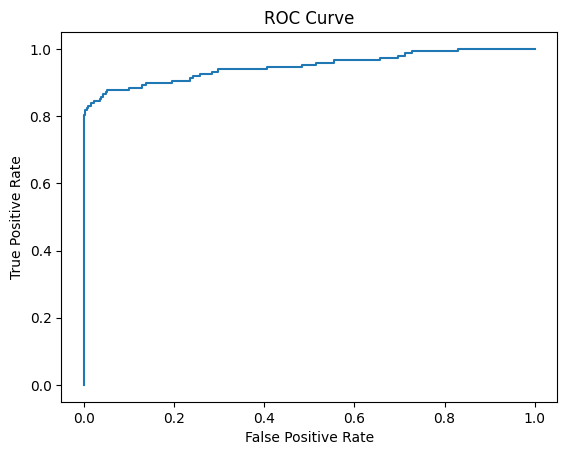

AUC:  0.9475633057290833


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC: ', roc_auc_score(y_test, y_probs))

Em problemas desbalanceados, como a fraude, a **Precision-Recall Curve** negrito mostra melhor o comportamento do modelo do que a curva ROC por si só.

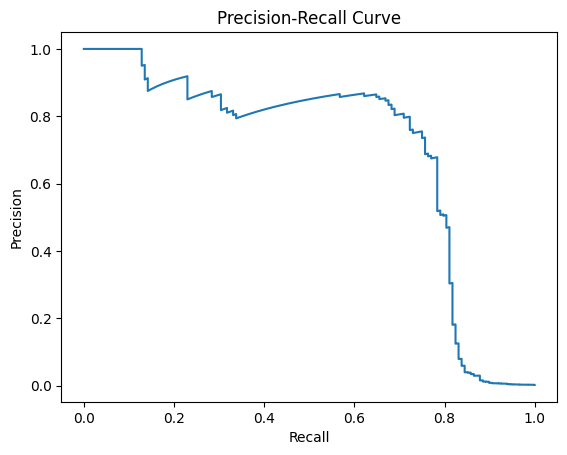

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

## Balanceamento de Dados

In [20]:
# Undesampling -> reduz a classe majoritária

fraudes = df[df['Class'] == 1]
nao_fraudes = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)

df_undersampled = pd.concat([fraudes, nao_fraudes])

In [21]:
# Oversampling  -> aumenta a classe minoritária

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)


2. RANDOM FOREST

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



## Conclusão:

Nesse caso, o modelo **Random Forest** se saiu melhor do que o modelo **Logistic Regression** na detecção das fraudes, por apresentar melhor **Recall** no resultado final.

# Aplicando Pipeline

In [35]:
from sklearn. pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)



## Threshold

O threshold padrão do modelo é de 0.5. Se a probabilidade de fraude for maior do que o valor do threshold o modelo classifica como fraude.
Ao diminuir esse valor podemos tornar o modelo mais criterioso da detecção das fraudes.


In [36]:
threshold = 0.2

y_pred_custom = (y_probs > threshold).astype(int)


print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.72      0.76       148

    accuracy                           1.00     85443
   macro avg       0.90      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost

XGBoost é um dos algoritmos mais usados em competições e mercado.

Ele é mais usado do que Random Forest para muitos problemas.

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:10:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



## Conclusão:

Nesse caso, o modelo **XGBoost** se saiu melhor do que o modelo **Ramdom Forest** na detecção das fraudes, por apresentar melhores métricas no resultado final: **Recall**, **Precision** e **F1-score**.

# Importância das variáveis


Ajuda a entender quais variáveis influenciam mais o modelo.


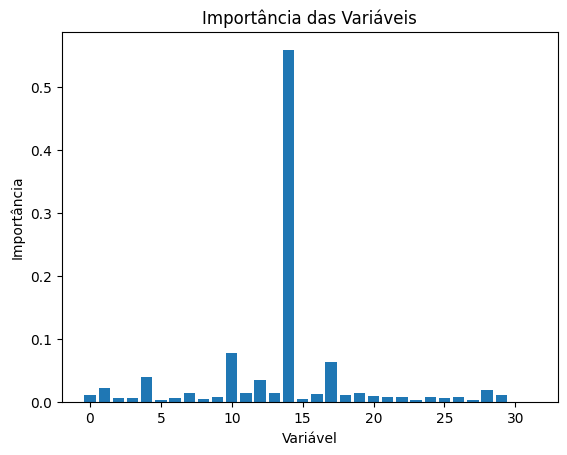

In [38]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title('Importância das Variáveis')
plt.xlabel('Variável')
plt.ylabel('Importância')
plt.show()

# Ajuste de hiperparâmetros

Testamos várias combinações para melhorar o modelo.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='recall'
)

grid.fit(X_train, y_train)

print('Melhor modelo: ', grid.best_params_)

Melhor modelo:  {'max_depth': 3, 'n_estimators': 100}


# Explicabilidade (SHAP)

**SHAP** mostra como cada variável infliencia a decisão do modelo.**negrito**


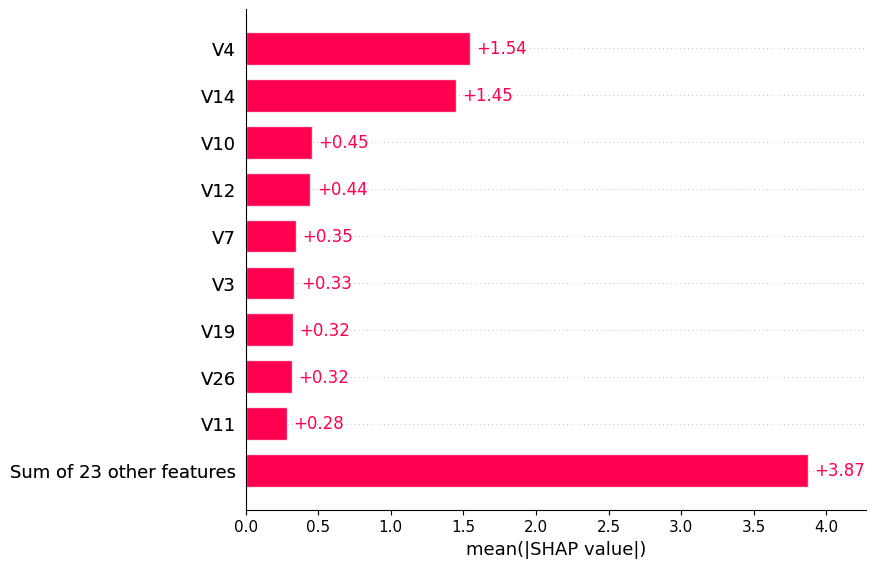

In [44]:
!pip install shap -q

import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

O **SHAP** é importante em quesitos de confiança, auditoria e uso em produção.

Ele apresenta os motivos que levaram o modelo a se comportar daquela forma.